# Homework 7 
Using Ulers method to solve dy/dx =-2y*cos(x), y(0) = 1

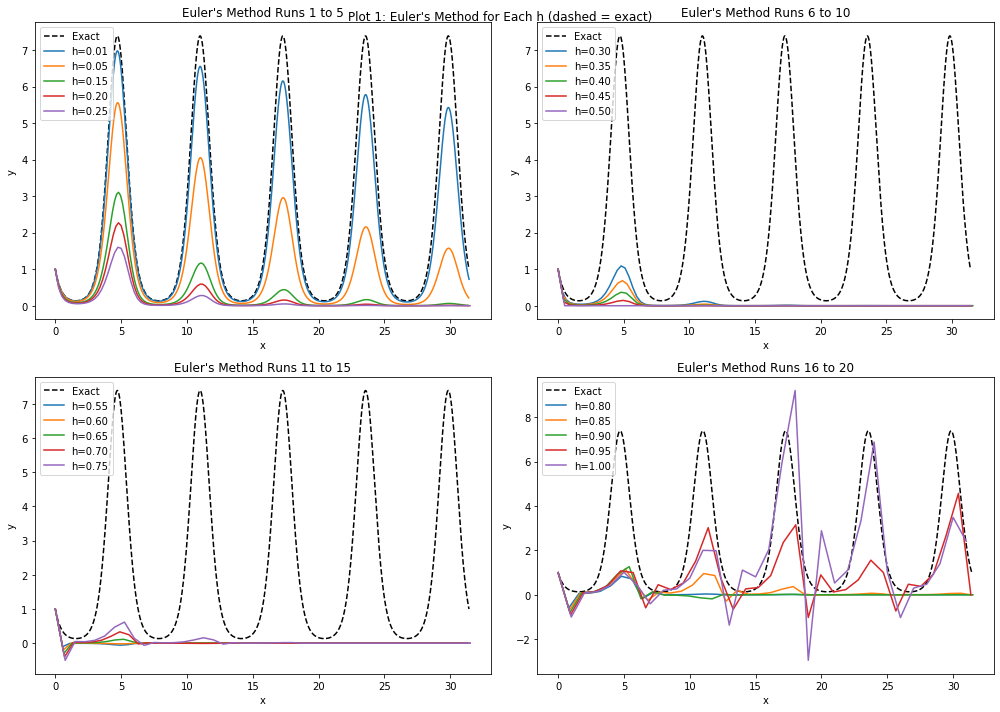

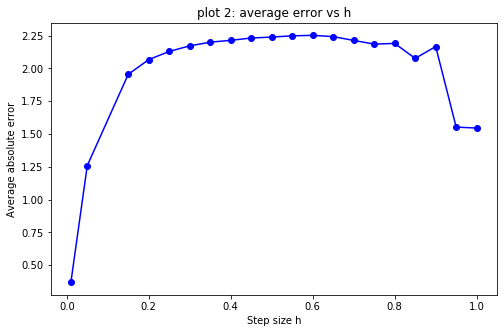

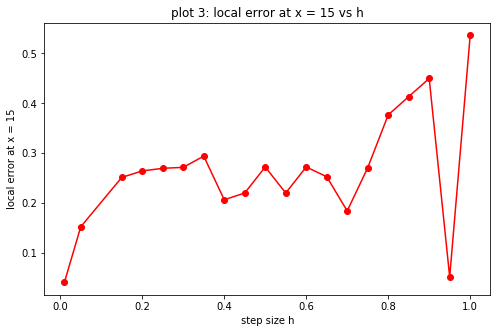

In [3]:
import numpy as np
import matplotlib.pyplot as plt


# Function representing dy/dx = -2y*cos(x)
def f(x, y):
    return -2 * y * np.cos(x)

# Exact solution - y = e^(-2sin(x))
def exact(x):  # solved for exact by hand (separable)
    return np.exp(-2 * np.sin(x))

def Euler(y_not, step, start, stop):

    # setup
    num_steps = int(round((stop - start) / step))
    x = np.linspace(start, stop, num_steps + 1)
    y = np.zeros(num_steps + 1)

    # initial condition
    x[0] = start
    y[0] = y_not

    # go through each step
    for i in range(num_steps):
        x[i+1] = x[i] + step
        y[i+1] = y[i] + step * f(x[i], y[i])
    return x, y

#intialize stuff
h_vals = [0.01, 0.05, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50,
          0.55, 0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 0.90, 0.95, 1.00]
avg_err = []
local_err_15 = []

# subplots to keep organized
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

#plot exact solution on each subplot 
x_exact_ref = np.linspace(0, 10 * np.pi, 1000)
y_exact_ref = exact(x_exact_ref)
for ax in axes:
    ax.plot(x_exact_ref, y_exact_ref, 'k--', linewidth=1.5, label='Exact')

# Implement Euler's method for each h
for j in range(len(h_vals)):

    h = h_vals[j]
    x, y = Euler(1, h, 0, 10 * np.pi)  # find approx

    y_exact = exact(x)

    globalErr = np.abs(y - y_exact)          
    avg_err.append(np.mean(globalErr)) 

    # error at x = 15
    i15 = np.argmin(np.abs(x - 15.0))  # step size doesn't let it be perfect so gotta round
    local_err_15.append(np.abs(y[i15] - exact(x[i15])))

    # choose what subplot it goes on
    plot_num = j // 5  # 5 lines per subplot
    if plot_num < 4:
        axes[plot_num].plot(x, y, label=f"h={h:.2f}")

# label each subplot
for k in range(4):
    axes[k].set_xlabel('x')
    axes[k].set_ylabel('y')
    axes[k].set_title(f"Euler's Method Runs {k*5 + 1} to {min((k+1)*5, len(h_vals))}")
    axes[k].legend()

plt.suptitle("Plot 1: Euler's Method for Each h (dashed = exact)")
plt.tight_layout()
plt.show()


# Plot 2: Average error vs h
plt.figure(figsize=(8, 5))
plt.plot(h_vals, avg_err, 'bo-')
plt.xlabel('Step size h')
plt.ylabel('Average absolute error')
plt.title('plot 2: average error vs h')

plt.show()


# Plot 3: Local error at x = 15 vs h
plt.figure(figsize=(8, 5))
plt.plot(h_vals, local_err_15, 'ro-')
plt.xlabel('step size h')
plt.ylabel('local error at x = 15')
plt.title('plot 3: local error at x = 15 vs h')

plt.show()

# Part 1 write up

For small step sizes the Euler approximation stays fairly similar to the exact solution. Because the exact solution oscillates over the interval, the approximation becomes noticeably worse as h increases. Larger step sizes cause more error to build up from step to step, so the numerical solution drifts farther from the exact solution.

The average global error generally increases as the step size increases. This matches plot 1, since larger step sizes do not capture the oscillating behavior of the exact solution as accurately as smaller step sizes.

The local error near x = 15 also generally increases with h. Smaller step sizes stay closer to the exact solution, while larger step sizes produce noticeably larger error near that point.

In [2]:
print("stability check using max cos(x)=1")
for h in h_vals:
    amp_max = abs(1 - 2*h*1)   # worst case when cos(x)=1
    print(f"h = {h:.2f}, worst-case amplification = {amp_max:.4f}")

stability check using max cos(x)=1
h = 0.01, worst-case amplification = 0.9800
h = 0.05, worst-case amplification = 0.9000
h = 0.15, worst-case amplification = 0.7000
h = 0.20, worst-case amplification = 0.6000
h = 0.25, worst-case amplification = 0.5000
h = 0.30, worst-case amplification = 0.4000
h = 0.35, worst-case amplification = 0.3000
h = 0.40, worst-case amplification = 0.2000
h = 0.45, worst-case amplification = 0.1000
h = 0.50, worst-case amplification = 0.0000
h = 0.55, worst-case amplification = 0.1000
h = 0.60, worst-case amplification = 0.2000
h = 0.65, worst-case amplification = 0.3000
h = 0.70, worst-case amplification = 0.4000
h = 0.75, worst-case amplification = 0.5000
h = 0.80, worst-case amplification = 0.6000
h = 0.85, worst-case amplification = 0.7000
h = 0.90, worst-case amplification = 0.8000
h = 0.95, worst-case amplification = 0.9000
h = 1.00, worst-case amplification = 1.0000


## Stability Analysis

for dy/dx = -2ycos(x) so if y'=lambda * y then lambda = -2cos(x)

Eulers method gets y(n+1) = yn(1-h*2*cos(xn)

So the stability condition is |1-2*h*cos(xn)| <= 1 because the next step should not be too big that it blows up

the worse case of of the stability condition is if cos(x) =1 so |1-2*h| <= 1 
this can be simplified to h<=1

This means This means the step size should be no bigger than 1 if you want that  stability condition to hold.



AI citations

- i coppied peices of code from the the last two challenges where i used ai to help me orgaize and simplify my code

I used chat gpt for everything

- prompt: how does the math work for stability analysis? explain the ideas in the most simple way.  (attached the slides)
- why: i didn't fully understand what stability anylisis was doing or why

- prompt: does my code make sense, work, and meet all requirments? (attached homework instructions and current code)
- why: I wanted to make sure my explainations were correct and i ddint miss anything important 